# 20260903-08 Modeling and Scaling

## Performance Modeling

Models give is a conceptual and roughly quantitative framework by which to answer the following types of questions.

* Why is an implementation exhibiting its observed performance?
* How will performance change if we:
  * optimize this component?
  * buy new hardware? (Which new hardware?)
  * run a different configuration?
* While conceptualizing a new algorithm, what performance can we expect and what will be bottlenecks?

Models are a guide for performance, but not an absolute.

### Terms

| Symbol | Meaning |
|--------|---------|
| $n$    | Input parameter related to problem size |
| $W$    | Amount of work to solve problem $n$ |
| $T$    | Execution time |
| $R$    | Rate at which work is done |

### Measuring work

**STREAM Triad:**

```c
for (i=0; i<n; i++)
    a[i] = b[i] + scalar*c[i];
```

$n$ is the array size.

Two ways of measuring "work".

**Compute:**
How many FLOPs are we doing?

$$W = 2 \cdot n$$

Rate $R=W/T$ is FLOP/s

**Memory:**
How much memory are we transfering?

$$W = 3 \cdot \texttt{sizeof(double)} \cdot n$$

Rate $R=W/T$ is bytes/s (usually MB/s)

#### Dense matrix multiplication
To perform the operation $C \gets C + A B$ where $A,B,C$ are $n\times n$ matrices.

```c
for (i=0; i<n; i++)
    for (j=0; j<n; j++)
        for (k=0; k<n; k++)
            c[i*n+j] += a[i*n+k] * b[k*n+j];
```

* Can you identify two expressions for the total amount of work $W(n)$ and the associated units?
* Can you think of a context in which one is better than the other and vice-versa?

Compute: $W = \mathcal{O}(n^3)$

Memory: $W = \mathcal{O}(n^2)$ (when done with care)

### Estimating time

To estimate time, we need to know how fast hardware executes flops and moves bytes.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas
import numpy as np
# plt.style.use('seaborn')

hardware = pandas.read_csv('data-intel.csv', index_col="Name")
hardware

,Year,GFLOPs-SP,GFLOPs-DP,Cores,Mem-GBps,TDP,Freq(MHz)
Name,,,,,,,
Xeon X5482,2007,102,51,4,26,150,3200
Xeon X5492,2008,108,54,4,26,150,3400
Xeon W5590,2009,106,53,4,32,130,3300
Xeon X5680,2010,160,80,6,32,130,3300
Xeon X5690,2011,166,83,6,32,130,3470
Xeon E5-2690,2012,372,186,8,51,135,2900
Xeon E5-2697 v2,2013,518,259,12,60,130,2700
Xeon E5-2699 v3,2014,1324,662,18,68,145,2300
Xeon E5-2699 v3,2015,1324,662,18,68,145,2300


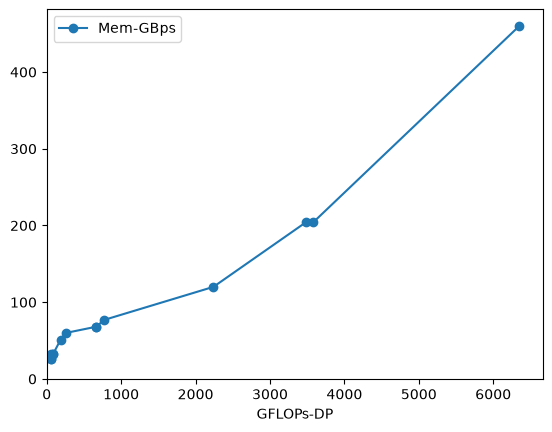

In [13]:
fig = hardware.plot(x='GFLOPs-DP', y='Mem-GBps', marker='o')
fig.set_xlim(left=0)
fig.set_ylim(bottom=0);

So we have rates $R_f = 4660 \cdot 10^9$ flops/second and $R_m = 175 \cdot 10^9$ bytes/second.  Now we need to characterize some algorithms.

In [3]:
algs = pandas.read_csv('algs.csv', index_col='Name')
algs['intensity'] = algs['flops'] / algs['bytes']
algs = algs.sort_values('intensity')
algs

,bytes,flops,intensity
Name,,,
Triad,24,2,0.083333
SpMV,12,2,0.166667
Stencil27-cache,24,54,2.250000
MatFree-FEM,2376,15228,6.409091
Stencil27-ideal,8,54,6.750000


In [7]:
def exec_time(machine, alg, n):
    bytes = n * alg.bytes
    flops = n * alg.flops
    T_mem = bytes / (machine['Mem-GBps'] * 1e9)
    T_flops = flops / (machine['GFLOPs-DP'] * 1e9)
    return max(T_mem, T_flops)
    
exec_time(hardware.loc['EPYC 9754'], algs.loc['Triad'], 1e9)

np.float64(0.05217391304347826)

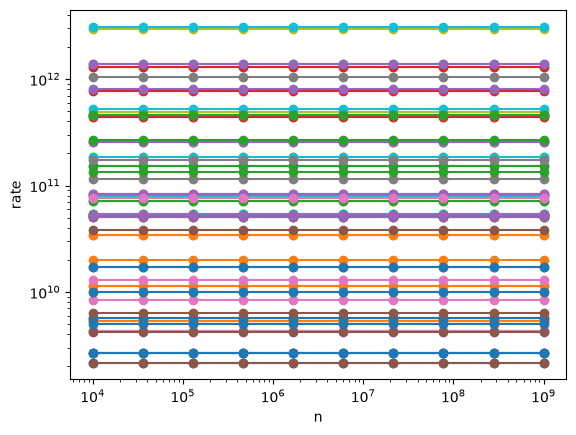

In [16]:
for _, machine in hardware.iterrows():
    for _, alg in algs.iterrows():
        ns = np.geomspace(1e4, 1e9, 10)
        times = np.array([exec_time(machine, alg, n) for n in ns])
        flops = np.array([alg.flops * n for n in ns])
        rates = flops/times
        plt.loglog(ns, rates, 'o-')
plt.xlabel('size of work (n)')
plt.ylabel('FLOP/s');

It looks like performance does not depend on problem size.

Well, yeah, we chose a model in which flops and bytes were both proportional to $n$, and our machine model has no sense of cache hierarchy or latency, so time is also proportional to $n$.  We can divide through by $n$ and yield a more illuminating plot.

Text(0, 0.5, 'rate')

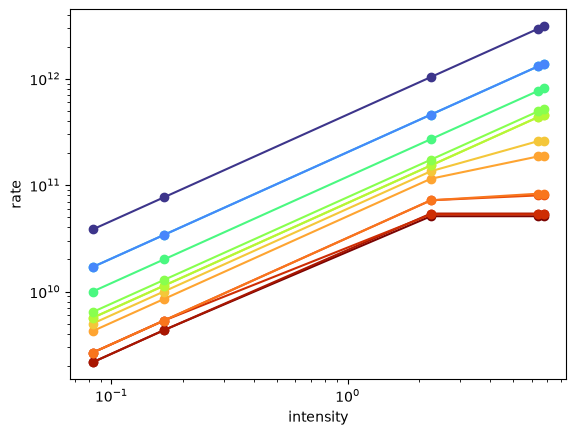

In [32]:
def MorphRangeTo01(value, range, morph_range = [0, 0.95]):
    return ((value - range[0]) / (range[-1] - range[0])) * (morph_range[1] - morph_range[0]) + morph_range[0]

for _, machine in hardware.iterrows():
    color = plt.cm.turbo_r(MorphRangeTo01(machine["Year"], [hardware["Year"].min(),hardware["Year"].max()]))
    times = np.array([exec_time(machine, alg, 1) 
                      for _, alg in algs.iterrows()])
    rates = algs.flops/times
    intensities = algs.intensity
    plt.loglog(intensities, rates, 'o-', label=machine.name, color=color)
plt.xlabel('intensity')
plt.ylabel('rate')
# plt.legend();

We're seeing the "roofline" for the older processors while the newer models are memory bandwidth limited for all of these algorithms.

### Recommended reading on single-node performance modeling
* [Williams, Waterman, Patterson (2009): **Roofline: An insightful visual performance model for multicore architectures**](https://doi.org/10.1145/1498765.1498785)

## Scaling: Programs with more than one part

So far, we've focused on simple programs with only one part, but real programs have several different parts, often with data dependencies.
Some parts will be amenable to optimization and/or parallelism and others will not.


![Diminishing returns](https://upload.wikimedia.org/wikipedia/commons/4/40/Optimizing-different-parts.svg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original)

The best possible performance you get with parallelization is governed by [Amdahl's Law](https://en.wikipedia.org/wiki/Amdahl%27s_law).

![Diminishing returns](https://upload.wikimedia.org/wikipedia/commons/e/ea/AmdahlsLaw.svg?utm_source=en.wikipedia.org&utm_campaign=imageinfo&utm_content=original)

In [68]:
def exec_time(f, p, n=100, latency=1):
    # Suppose that a fraction f of the total work is amenable to optimization
    # We run a problem size n with parallelization factor p
    return latency + (1-f)*n + f*n/p

$$ T = \ell + (1-f)\cdot n + f\cdot n / p$$

| Symbol | Meaning |
| --- | --- |
| $T$ | Time taken to run |
| $\ell$| Latency (startup time and time waiting for communication) |
| $f$ | Fraction of work that is parallelizable |
| $n$ | Amount of work |
| $p$ | Total processes parallelized over |

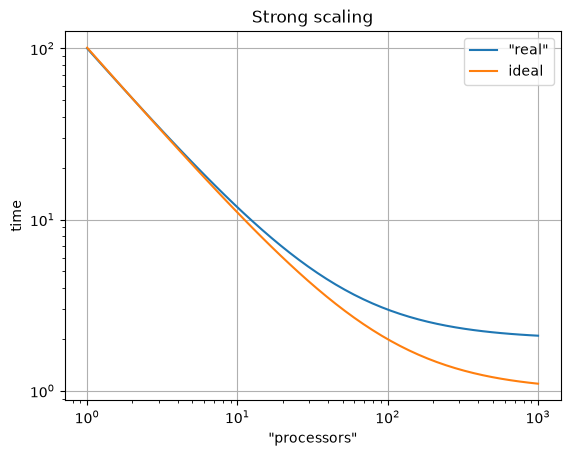

In [77]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas
import numpy as np

ps = np.geomspace(1, 1000)

plt.loglog(ps, exec_time(.98, ps, latency=0), label="\"real\"")
plt.loglog(ps, exec_time(1, ps, latency=1), label="ideal")
plt.title('Execution time with increased parallelization')
plt.xlabel('"processors"')
plt.ylabel('time')
plt.grid()
plt.legend();

### Strong scaling: fixed total problem size

- Good strong scaling == being able to go faster at the same cost (assuming you have the resources)
- This is the one we all want, but is really difficult to get

#### Cost = `time * p`

- Often compute allocations are given in terms of "node-hours" or "CPU-hours"
- Therefore, we must balance total execution time with cost
    - We can use more resources simultaneously to go faster, and thus use those resources for a smaller amount of time
    - But without perfect scalability, using more resources increases costs due to inefficiencies

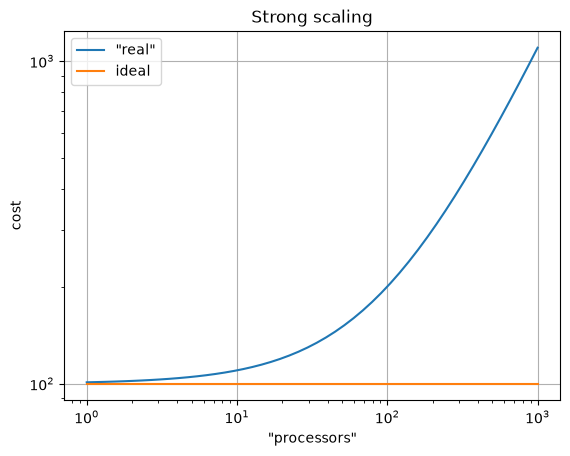

In [82]:
def exec_cost(f, p, **kwargs):
    return exec_time(f, p, **kwargs) * p

plt.loglog(ps, exec_cost(1, ps, latency=), label='"real"')
plt.loglog(ps, exec_cost(1, ps, latency=0), label='ideal')
plt.title('Strong scaling')
plt.xlabel('"processors"')
plt.ylabel('cost')
plt.legend()
plt.grid();

#### Efficiency

$$E = \frac{n}{T p}$$
$$\Rightarrow E =  \frac{n}{\ell p} + \frac{1}{(1 - f) p} + \frac{1}{f}$$

- We will ignore the $n$, as it's difficult to quantify in real life the units of "problem size" in a way that makes sense

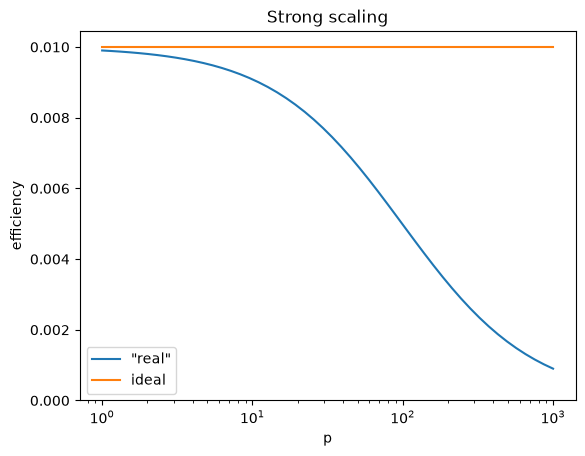

In [83]:
plt.semilogx(ps, 1/exec_cost(.9999, ps, latency=1), label='"real"')
plt.semilogx(ps, 1/exec_cost(1, ps, latency=0), label='ideal')
plt.title('Strong scaling')
plt.xlabel('p')
plt.ylabel('efficiency')
plt.legend()
plt.ylim(bottom=0);

#### Speedup

$$ S(p) = \frac{T(1)}{T(p)} $$

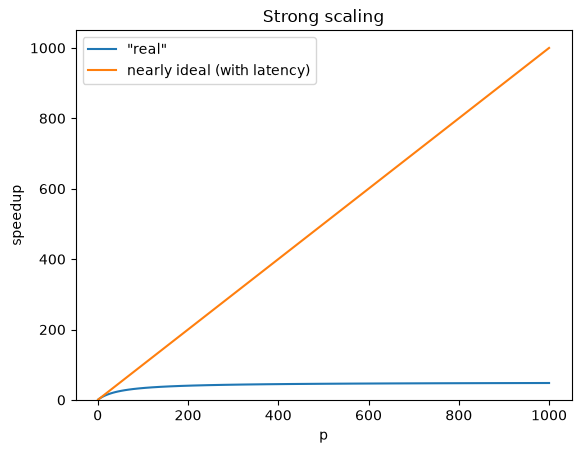

In [86]:
plt.plot(ps, exec_time(.99, 1, latency=1) / exec_time(.99, ps, latency=1), label='"real"')
plt.plot(ps, exec_time(1, 1, latency=.0) / exec_time(1, ps, latency=0), label='nearly ideal (with latency)')
plt.title('Strong scaling')
plt.xlabel('p')
plt.ylabel('speedup')
plt.legend()
plt.ylim(bottom=0);

### Stunt 1: Report speedup, not absolute performance!

![Hager](stunt1.jpg)

From https://blogs.fau.de/hager/archives/5299

Also see [Stunt 2](https://blogs.fau.de/hager/archives/5429) for related discussion

- Strong scaling looks really good when the serial part is really inefficient

### Efficiency-Time spectrum (Jed's preference)

People care about two observable properties
* **Time** until job completes
* **Cost** in core-hours or dollars to do job

Together, they show the balance of "How much extra do I need to pay to go X amount faster?".

Most HPC applications have access to large machines, so don't really care how many processes they use for any given job.

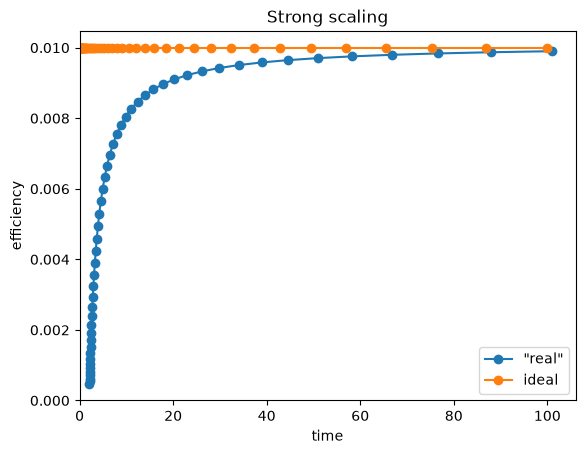

In [53]:
plt.plot(exec_time(.99, ps), 1/exec_cost(.99, ps), 'o-', label='"real"')
plt.plot(exec_time(1, ps, latency=0), 1/exec_cost(1, ps, latency=0), 'o-', label="ideal")
plt.title('Strong scaling')
plt.xlabel('time')
plt.ylabel('efficiency')
plt.ylim(bottom=0);
plt.legend();
plt.xlim(left=0);

#### Principles of reporting scaling and performance
* [No "soft" `log` scale](https://blogs.fau.de/hager/archives/5835)
* Both axes have tangible units
* Bigger is better on the $y$ axis
    - Makes it easier to understand what is doing better than something else

### Weak Scaling: Fixed work per processor

- We've kept the problem size $n$ fixed thus far, but parallel computers are also used to solve large problems.  
- If we keep the amount of work per processor fixed, we are [weak/Gustafson scaling](https://en.wikipedia.org/wiki/Gustafson's_law).

- If strong scaling says we can go faster, weak scaling says we can go bigger
    - If we increase our problem size by N times and use N times the resources, do we take the same amount of time to compute?
    - A different target, much easier to hit (not impacted by latency as much

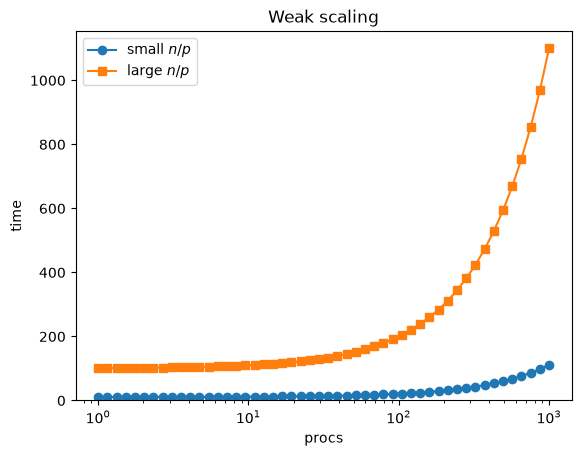

In [58]:
ns = 10*ps
plt.semilogx(ps, exec_time(.99, ps, n=ns, latency=1), 'o-', label="small $n/p$")
ns = 100*ps
plt.semilogx(ps, exec_time(.99, ps, n=ns, latency=1), 's-', label="large $n/p$")
plt.title('Weak scaling')
plt.xlabel('procs')
plt.ylabel('time')
plt.legend()
plt.ylim(bottom=0);

#### Weak scaling via efficiency

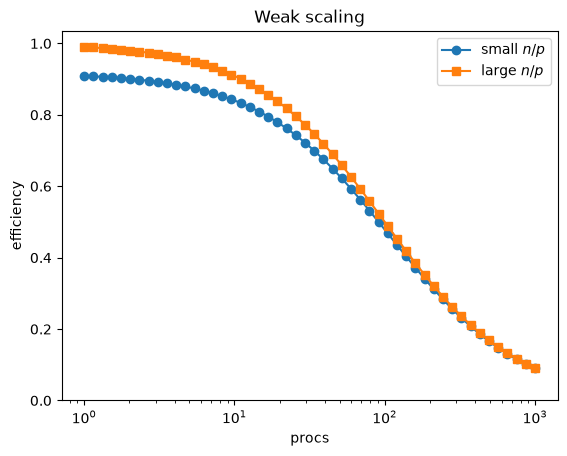

In [64]:
ns = 10*ps
plt.semilogx(ps, ns/exec_cost(.99, ps, n=ns, latency=1), 'o-', label="small $n/p$")
ns = 100*ps
plt.semilogx(ps, ns/exec_cost(.99, ps, n=ns, latency=1), 's-', label="large $n/p$")
plt.title('Weak scaling')
plt.xlabel('procs')
plt.ylabel('efficiency')
plt.legend()
plt.ylim(bottom=0);

Recall
$$E =  \frac{n}{\ell p} + \frac{1}{(1 - f) p} + \frac{1}{f}$$

- The latency term is constant when $n/p$ is fixed
- $E$ is only *really* sensitive to the parallelizablility

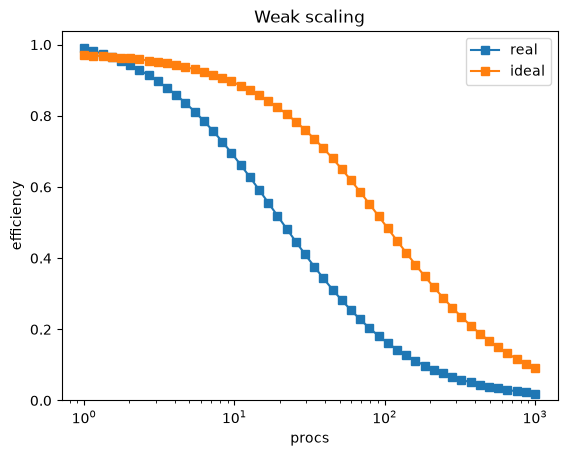

In [132]:
ns = 100*ps
plt.semilogx(ps, ns/exec_cost(.95, ps, n=ns, latency=1), 's-', label="real")
plt.semilogx(ps, ns/exec_cost(.99, ps, n=ns, latency=3), 's-', label="ideal")
plt.title('Weak scaling')
plt.xlabel('procs')
plt.ylabel('efficiency')
plt.legend()
plt.ylim(bottom=0);


<div class="alert alert-block alert-danger">
<b></b> 
On real machines, latency is often also a function of $p$; increased network traffic, network topology, different communication standards used depending on hardware (is $p$ on a single node of a machine? A single CPU socket?)
</div>

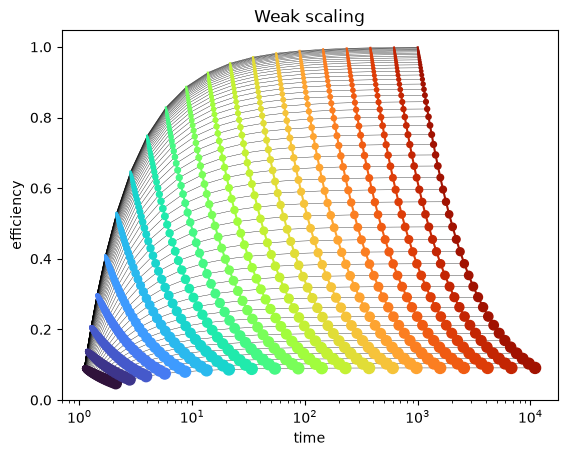

In [127]:
def MorphRangeTo01(value, range, morph_range = [0, 0.95]):
    return ((value - range[0]) / (range[-1] - range[0])) * (morph_range[1] - morph_range[0]) + morph_range[0]

ws = np.geomspace(0.1, 1e3, 20) # problem size per processor
exec_time_kwargs = {'f': 0.99, 'latency': 1}

for p in ps:
    ns = ws*p
    color = 'k'
    plt.semilogx(exec_time(p=p, n=ns, **exec_time_kwargs),
                 ns/exec_cost(p=p, n=ns, **exec_time_kwargs), color=color, linewidth=0.25, zorder=-10)

for w in ws:
    ns = w*ps
    color = plt.cm.turbo(MorphRangeTo01(np.log(w), np.log([ws.min(),ws.max()])))
    plt.semilogx(exec_time(p=ps, n=ns, **exec_time_kwargs),
                 ns/exec_cost(p=ps, n=ns, **exec_time_kwargs), '-', color=color)
    plt.scatter(exec_time(p=ps, n=ns, **exec_time_kwargs),
                 ns/exec_cost(p=ps, n=ns, **exec_time_kwargs), marker='o', color=color, s = 70*MorphRangeTo01(np.log(ps), np.log([ps.min(),ps.max()]))**2)

plt.title('Weak scaling')
plt.xlabel('time')
plt.ylabel('efficiency')
plt.ylim(bottom=0);

- Colors are fixed work-per-processor (red large, blue small)
- Dot size relates to number processors

e.g.
- "Vertical" lines are constant work-pre-processor
- "Horizontal" lines are constant processor count

- Efficiency sensitive to number of processors
- Time sensitive to work-per-processor

### Weak vs Strong scaling summary

| Thing | Strong Scaling | Weak Scaling |
| --- | --- | --- |
| Fixes | Problem size | Problem size-per processor |
| Most sensitive to... | latency | parallelizability |
| Answers "If I have more resources, ..." | how much **faster** can I run efficiently? | how much **larger** (of a problem) can I run efficiently? |

Both have to establish what a representative problem size is.
- Strong scaling has to set an initial problem size
- Weak scaling needs to set a size-per-processor

Plenty of shenanigans can be had when deciding what the "representative" problem size is.

### "Normal" scaling metrics are not always the best

From [Fuhrer et al (2018): Near-global climate simulation at 1 km resolution](https://www.geosci-model-dev.net/11/1665/2018/gmd-11-1665-2018.pdf)

![Fuhrer (2018)](fuhrer2018-fig4.png)

Goal is to have 1 simulated year-per-day (SYMD, the rate of computation) at a 1km resolution (effectively the size of the problem).

This plot seems to show that GPUs get us closer to that goal.

Jed replotted these data for [his talk](https://jedbrown.org/files/20190822-Latsis.pdf) at the [Latsis Symposium](https://latsis2019.ethz.ch/) in 2019.

![Fuhrer (2018) replotted](fuhrer2018-scaling-time-ann4.png)

By examing the properties of the problem more specifically, we get a much better informed understanding of how the performance of the code translates into tangible.
- The climate simulation splits the "simulated year" into individual steps
- The higher the physical resolution (e.g. 1km), the smaller the steps must be (and the more number of steps in a single "simulated year")
- With the goal of doing a simulated year per (wall-clock) day, we can compute the time necessary to complete each step
    - This is the x axis "time per step"
- The y-axis is the amount of compute done per node
    - This is effectively the $n/p$ quantity for weak scaling

- Latency is the much more significant bottle neck for these computations them outright compute
- GPUs aren't really the answer
- Moore Money
    - We can always buy more processors/GPUs to get more compute capability
- Moore Problems
    - There a limit for how low latency penalty can take when communicating between parallel processors
    - This is physics problem, not a technological one

This highlights the need for **different approaches** for solving the problem, not **different implementations** (e.g. better algorithms for hardware)
- Jed specifically focuses on using a different time discretization scheme which allows for less steps for a single simulated year (and thus reducing the required "time per step" necessary to reach 1 SYPD @ 1km)

This issue is very similar to the so-called [LES Crisis](https://www-tandfonline-com.colorado.idm.oclc.org/doi/full/10.1080/10618562.2019.1612052) on the more engineering side of HPC.

### Further resources
* [Hager: Fooling the masses](https://blogs.fau.de/hager/archives/category/fooling-the-masses)
  * Learn by counter-examples
* [Hoefler and Belli: Scientific Benchmarking of Parallel Computing Systems](https://htor.inf.ethz.ch/publications/index.php?pub=222)
  * Recommended best practices, especially for dealing with performance variability
